# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Experiment 11

Summary: Try to improve the performance achieved in experimentFour (predicted 10 days in the future, based on observations from 30 days in the past).

Important differences:
- Go back to predicting 10 days into the future (as in experimentTen)
- Change the sequence length from 10 days (in experimentFour) to 30 days 
- Change num_generations from 1000 to 400 (as in experimentTen)
- Change number of solutions from 20 to 10 (as in experimentTen)
- Change of num_parents_mating from 10 to 5 (as in experimentTen)

## Preparing the data

### Transforming the csv data to a numpy array

In [1]:
import numpy as np

str_to_np_date = lambda x: np.datetime64(x)

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=1)
usdYen_raw_data_dates = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=0, converters={0: str_to_np_date})

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)
print("Raw Data Dates: ",usdYen_raw_data_dates)

Length:  5000
Data type:  float64
Raw Data:  [154.71 155.21 155.81 ... 118.22 118.89 118.46]
Raw Data Dates:  ['2025-12-16' '2025-12-15' '2025-12-12' ... '2006-10-19' '2006-10-18'
 '2006-10-17']


As the currency data is from newer to older, the order should be inverted.

In [2]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[118.46 118.89 118.22 ... 155.81 155.21 154.71]


### Computing the numer of samples for each data split

In [3]:
train_samples_number = len(usdYen_raw_data)
print("Number of train samples: ", train_samples_number)

Number of train samples:  5000


### Creating timeseries data

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [4]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 30 # Observations will go back 30 days
delay = sampling_rate * (sequence_length + 10 - 1) # target is 10 days after the end of the sequence
batch_size = train_samples_number

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

### - Checking that timeseries data works correctly

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [5]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[118.46, 118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21, 117.74, 118.02, 117.92, 116.72, 116.28, 115.83, 116.09] 116.97
[118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21, 117.74, 118.02, 117.92, 116.72, 116.28, 115.83, 116.09, 116.16] 116.76
[118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21, 117.74, 118.02, 117.92, 116.72, 116.28, 115.83, 116.09, 116.16, 116.39] 117.56
[118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15, 117.6, 118.01, 118.21, 117.74, 118.02, 117.92, 116.72, 116.28, 115.83, 116.09, 116.16, 116.39, 115.8] 117.83
[119.34, 119.42, 119.01, 118.

2026-01-14 11:11:34.683262: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### - Extracting data inputs and outputs

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [6]:
import tensorflow as tf

data_inputs = []
data_outputs = []

for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
    data_outputs = tf.reshape(tf.make_ndarray(tf.make_tensor_proto(targets)), [-1,1])

data_inputs_test = data_inputs[-200:]
data_outputs_test = data_outputs[-200:]
data_inputs = data_inputs[:-200]
data_outputs = data_outputs[:-200]

print("Data Inputs: ", len(data_inputs))
print("Data Inputs Test: ", len(data_inputs_test))
print("Data Outputs: ", len(data_outputs))
print("Data Outputs Test: ", len(data_outputs_test))
    

Samples:  tf.Tensor(
[[118.46 118.89 118.22 ... 116.28 115.83 116.09]
 [118.89 118.22 118.7  ... 115.83 116.09 116.16]
 [118.22 118.7  119.34 ... 116.09 116.16 116.39]
 ...
 [147.41 147.46 147.2  ... 150.42 150.62 150.74]
 [147.46 147.2  147.66 ... 150.62 150.74 151.93]
 [147.2  147.66 147.4  ... 150.74 151.93 151.97]], shape=(4932, 30), dtype=float64)
Sample shape:  (4932, 30)
Targets:  tf.Tensor([116.97 116.76 117.56 ... 154.21 153.67 154.11], shape=(4932,), dtype=float64)
Targets shape:  (4932,)
Data Inputs:  4732
Data Inputs Test:  200
Data Outputs:  4732
Data Outputs Test:  200


2026-01-14 11:11:34.888628: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
print("----")
print("Input Data: ", data_inputs)
print("----")
print("Output Data: ", data_outputs)
print("----")

----
Input Data:  [[118.46  118.89  118.22  ... 116.28  115.83  116.09 ]
 [118.89  118.22  118.7   ... 115.83  116.09  116.16 ]
 [118.22  118.7   119.34  ... 116.09  116.16  116.39 ]
 ...
 [149.59  150.539 150.073 ... 158.109 157.657 157.459]
 [150.539 150.073 149.989 ... 157.657 157.459 157.948]
 [150.073 149.989 151.204 ... 157.459 157.948 156.435]]
----
Output Data:  tf.Tensor(
[[116.97 ]
 [116.76 ]
 [117.56 ]
 ...
 [154.502]
 [155.501]
 [155.191]], shape=(4732, 1), dtype=float64)
----


## Simple LSTM Model

In [8]:
from keras import models
from keras import layers
from keras import activations

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(16, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(8, activation=activations.linear))
    model.add(layers.Dense(1, activation=activations.linear))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    model.summary()
    return model

prototype_model = build_lstm_model()

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

## Genetic Algorithm

The code for the Genetic Algorithm is based on the code provided by the PyGAD library documentation [2].

### - Instance of the pygad.kerasga.KerasGA class

In [9]:
import pygad.kerasga

keras_ga = pygad.kerasga.KerasGA(model=prototype_model, num_solutions=10)

### - Fitness function

In [10]:
def fitness_function(ga_instance, solution, solution_index):
    global data_inputs, data_outputs, keras_ga, prototype_model
    predictions = pygad.kerasga.predict(model=prototype_model, solution=solution, data=data_inputs)
    mae = keras.losses.MeanAbsoluteError()
    absolute_error = mae(data_outputs, predictions).numpy() + 0.00000001
    solution_fitness = 20 / absolute_error
    return solution_fitness

### - Track GA

In [11]:
def on_generation(ga_instance):
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution()[1]}")

### - Create instance of the pygad.GA class

In [12]:
num_generations = 500
num_parents_mating = 5
initial_population = keras_ga.population_weights

ga_instance = pygad.GA(
                        num_generations=num_generations,
                        num_parents_mating=num_parents_mating,
                        initial_population=initial_population,
                        fitness_func=fitness_function,
                        on_generation=on_generation,
                        suppress_warnings=True,
                        parallel_processing=["thread", 4]
                       )

In [13]:
ga_instance.summary()

----------------------------------------------------------------------
                           PyGAD Lifecycle                           
Step                  Handler                          Output Shape
Fitness Function      fitness_function()               (1)         
----------------------------------------------------------------------
Parent Selection      steady_state_selection()         (5, 1297)   
Number of Parents: 5
----------------------------------------------------------------------
Crossover             single_point_crossover()         (5, 1297)   
----------------------------------------------------------------------
Mutation              random_mutation()                (5, 1297)   
Mutation Genes: 129
Random Mutation Range: (-1.0, 1.0)
Mutation by Replacement: False
Allow Duplicated Genes: True
----------------------------------------------------------------------
On Generation         on_generation()                  None        
-------------------------------

"----------------------------------------------------------------------\n                           PyGAD Lifecycle                           \n======================================================================\nStep                  Handler                          Output Shape\n======================================================================\nFitness Function      fitness_function()               (1)         \n----------------------------------------------------------------------\nParent Selection      steady_state_selection()         (5, 1297)   \nNumber of Parents: 5\n----------------------------------------------------------------------\nCrossover             single_point_crossover()         (5, 1297)   \n----------------------------------------------------------------------\nMutation              random_mutation()                (5, 1297)   \nMutation Genes: 129\nRandom Mutation Range: (-1.0, 1.0)\nMutation by Replacement: False\nAllow Duplicated Genes: True\n----------

In [14]:
ga_instance.run()

Generation = 1
Fitness    = 0.19123807549476624
Generation = 2
Fitness    = 0.19123807549476624
Generation = 3
Fitness    = 0.19374412298202515
Generation = 4
Fitness    = 0.20223581790924072
Generation = 5
Fitness    = 0.20223581790924072
Generation = 6
Fitness    = 0.2036297768354416
Generation = 7
Fitness    = 0.20926634967327118
Generation = 8
Fitness    = 0.21022340655326843
Generation = 9
Fitness    = 0.2136244922876358
Generation = 10
Fitness    = 0.21867266297340393
Generation = 11
Fitness    = 0.21978791058063507
Generation = 12
Fitness    = 0.22319218516349792
Generation = 13
Fitness    = 0.22871463000774384
Generation = 14
Fitness    = 0.2380697876214981
Generation = 15
Fitness    = 0.2380697876214981
Generation = 16
Fitness    = 0.24111635982990265
Generation = 17
Fitness    = 0.25846022367477417
Generation = 18
Fitness    = 0.25846022367477417
Generation = 19
Fitness    = 0.2608502507209778
Generation = 20
Fitness    = 0.2608502507209778
Generation = 21
Fitness    = 0.2688

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


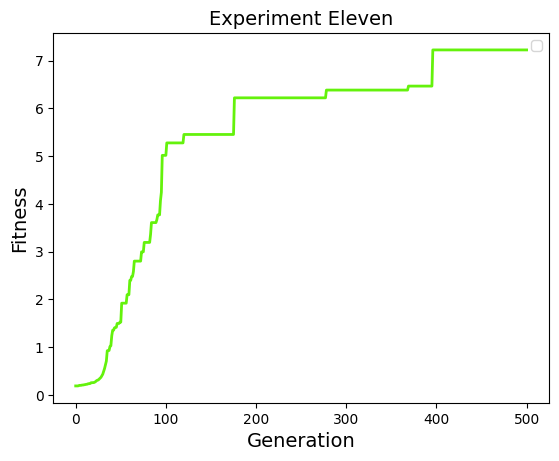

Figure(640x480)


In [15]:
print(ga_instance.plot_fitness(title="Experiment Eleven", linewidth=2))

### - Run best solution

In [16]:
solution, solution_fitness, solution_index = ga_instance.best_solution()
predictions = pygad.kerasga.predict(model=prototype_model, solution=solution,data=data_inputs)
mae = keras.losses.MeanAbsoluteError()
absolute_error = mae(data_outputs, predictions).numpy()
print("Solution fitness: ", solution_fitness, " (20 is the best)")
print("Predictions: ", predictions)
print("Absolute Error: ", absolute_error)

Solution fitness:  7.223391  (20 is the best)
Predictions:  [[115.87314]
 [115.87039]
 [116.02963]
 ...
 [145.55304]
 [145.78534]
 [145.06003]]
Absolute Error:  2.7687826


### - Save Genetic Algorithm and export ML model

**Save Genetic Algorithm**

In [17]:
ga_instance.save(filename="genetic-algorithms/genetic_algorithm_experiment_eleven")

**Export model (keras and tensorflow)**

In [18]:
# Get the best solution as a keras weight matrix
ga_best_solution_weights = pygad.kerasga.model_weights_as_matrix(model=prototype_model, weights_vector=solution)

# Set the weights
prototype_model.set_weights(ga_best_solution_weights)

In [19]:
# Save the model (for Keras)
prototype_model.save("models/experiment_eleven_prototype_model.keras")

# Save the model (for Tensorflow)
prototype_model.export("models/experiment_eleven_prototype_model_tf", format="tf_saved_model")

INFO:tensorflow:Assets written to: models/experiment_eleven_prototype_model_tf/assets


INFO:tensorflow:Assets written to: models/experiment_eleven_prototype_model_tf/assets


Saved artifact at 'models/experiment_eleven_prototype_model_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  6059631312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6059629776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6059629200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6059628816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6059633232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6059632848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  6059633808: TensorSpec(shape=(), dtype=tf.resource, name=None)


## Prediction using loaded model

### - Load model and make a prediction

Load the model

In [20]:
from keras.models import load_model

loaded_model = load_model("models/experiment_eleven_prototype_model.keras")

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 9 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Make a prediction

In [21]:
keras_predictions_loaded_model = loaded_model.predict(data_inputs)
mae_loaded_model = keras.losses.MeanAbsoluteError()
absolute_error_loaded_model = mae(data_outputs, keras_predictions_loaded_model).numpy()
print("Predictions (loaded_model): ", keras_predictions_loaded_model)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model)

148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predictions (loaded_model):  [[115.87314]
 [115.87039]
 [116.02963]
 ...
 [145.55304]
 [145.78534]
 [145.06003]]
Absolute Error (loaded_model):  2.7687826


Same Absolute Error as the best solution of the Genetic Algorithm. This means that the model was saved correctly.

### - Test loaded model using test data

Using test_data check the MAE of the model. This data has not been used before, and thus works as a good way of measuring the performance of the model.

In [22]:
keras_predictions_loaded_model_with_test_data = loaded_model.predict(data_inputs_test)
absolute_error_loaded_model_with_test_data = mae(data_outputs_test, keras_predictions_loaded_model_with_test_data).numpy()
print("Predictions (loaded_model with test data): ", keras_predictions_loaded_model_with_test_data)
print("Absolute Error (loaded_model): ", absolute_error_loaded_model_with_test_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predictions (loaded_model with test data):  [[144.48538]
 [145.13457]
 [144.70944]
 [144.5632 ]
 [145.24171]
 [144.93958]
 [144.9248 ]
 [144.20226]
 [144.80605]
 [144.57928]
 [144.13324]
 [144.65439]
 [144.33598]
 [144.1794 ]
 [143.24597]
 [142.62802]
 [142.73901]
 [143.08282]
 [143.31212]
 [144.33801]
 [143.31735]
 [143.14986]
 [142.71555]
 [143.10902]
 [142.69693]
 [141.60011]
 [141.54044]
 [141.81854]
 [141.33987]
 [141.44461]
 [141.8946 ]
 [142.29099]
 [141.55429]
 [141.86884]
 [141.20468]
 [140.70755]
 [140.8115 ]
 [140.18896]
 [140.67513]
 [140.92447]
 [140.56107]
 [141.21188]
 [141.45139]
 [141.47229]
 [141.1804 ]
 [141.19882]
 [141.53432]
 [142.36089]
 [141.73967]
 [142.22902]
 [142.47314]
 [141.68958]
 [141.8653 ]
 [141.65147]
 [141.06076]
 [139.2157 ]
 [140.25313]
 [140.61423]
 [139.54434]
 [140.4956 ]
 [138.20386]
 [137.85423]
 [137.49774]
 [137.72163]
 [136.49904]
 [137.30981]
 [136.92143]
 [135.88293]
 [137.50674]
 [137.64912]
 [137.261

Visualize predicted values

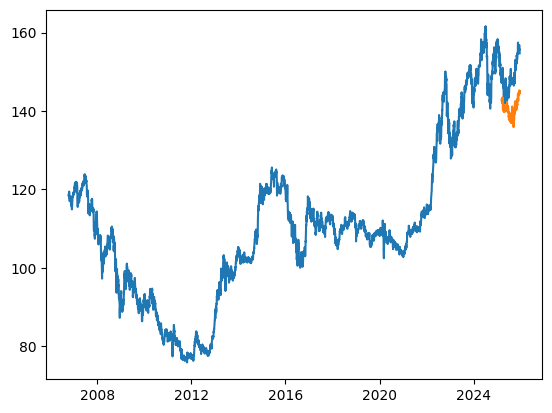

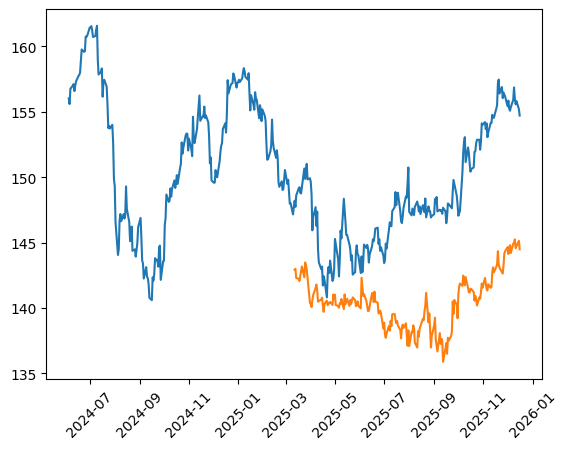

In [23]:
import matplotlib.pyplot as plt

# Flip data as it flips back again for some reason
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)

# Full data
plt.plot(usdYen_raw_data_dates, usdYen_raw_data)
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
plt.show()

# Zoom in on data
fig, ax = plt.subplots()
plt.plot(usdYen_raw_data_dates[:400], usdYen_raw_data[:400])
plt.plot(usdYen_raw_data_dates[:200], keras_predictions_loaded_model_with_test_data)
ax.tick_params("x", rotation=45)
plt.show()

## About the code

The timeseries data code is based on the code shown in the chapter of the book Deep Learning with Python.

The Genetic Algorithm code is based on the code shown in the docs of the PyGAD library.

## References

1- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries, Preparing the data. Retrieved from https://learning.oreilly.com/library/view/deep-learning-with/9781617296864/Text/10.htm#heading_id_5

2- PyGAD. pygad.kerasga Module. Retrieved from https://pygad.readthedocs.io/en/latest/kerasga.html#